In [5]:
import pandas as pd
data = pd.read_excel("default of credit card clients.xls")

data.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [6]:
data = data.iloc[1:].copy()

print("First extra row removed!")
print("Rows:", len(data))

First extra row removed!
Rows: 30000


In [7]:
data = data.apply(pd.to_numeric, errors = 'coerce')

print("Data converted to numeric!")

Data converted to numeric!


In [8]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [10]:
print(data['Y'].value_counts())

Y
0    23364
1     6636
Name: count, dtype: int64


In [11]:
X = data.drop('Y', axis = 1)
y = data['Y'].astype(int)
print("Features and target seperated!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target seperated!
X shape: (30000, 24)
y shape: (30000,)


In [12]:
X = X.drop('Unnamed: 0', axis = 1)

print("ID column removed!")
print("X shape:", X.shape)

ID column removed!
X shape: (30000, 23)


In [13]:
X['Avg_Payment_Status'] = X[['X6', 'X7', 'X8', 'X9', 'X10', 'X11']].mean(axis = 1)

print("Feature engineering completed!")
print("X shape:", X.shape)

Feature engineering completed!
X shape: (30000, 24)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("Train-tst split completed!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:, y_test.shape")

Train-tst split completed!
X_train: (24000, 24)
X_test: (6000, 24)
y_train: (24000,)
y_test:, y_test.shape


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [17]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled) [:, 1]

print("Predictions completed!")

Predictions completed!


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.6883116883116883
Recall: 0.23963828183873398
F1-score: 0.3555058692006708


In [19]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7076276017481496


In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4529  144]
 [1009  318]]


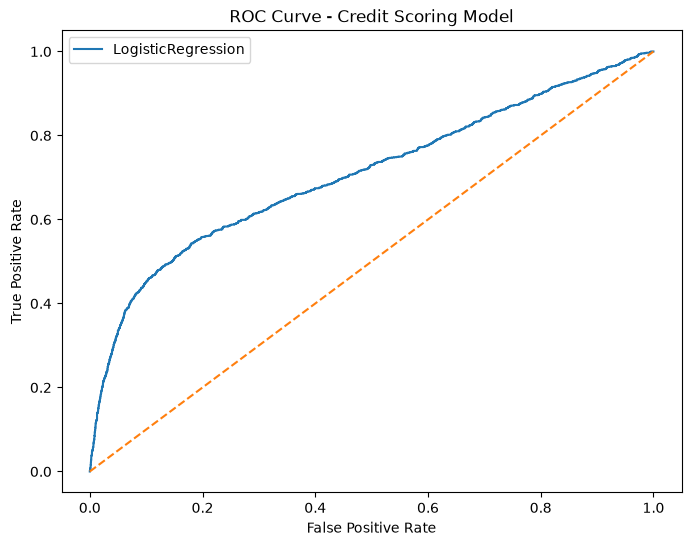

In [22]:
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, label = "LogisticRegression")
plt.plot([0,1], [0,1], linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Scoring Model")
plt.legend()
plt.show()

## Conclusion
A Logistic Regression model was developed tp predict credit card default.
Feature engineering was performed by creating an average payment-status feature. The model was evaluated using Precision, Recall, F1-Score and ROC-AUC.
The results show how well the model can distingusih between customers who are likely to default and those who are not.